# Heat Loss Prediction

## 0. library

In [80]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from numba import jit
import random

def set_all_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_all_seeds(42)

## 2. data process


### (1) load data

In [ ]:
df = pd.read_csv('hoje_taastrup_10min.csv',index_col=0)
df.index = pd.to_datetime(df.index)
A_strings = [c for c in df.columns if c.startswith('A')]
A_strings.sort()

# load the data required for the greybox model
water = df[A_strings]
tair = df['T_amb']
tair = tair.interpolate(method='linear')
heat_loss = df['heatloss']

### (2) resample

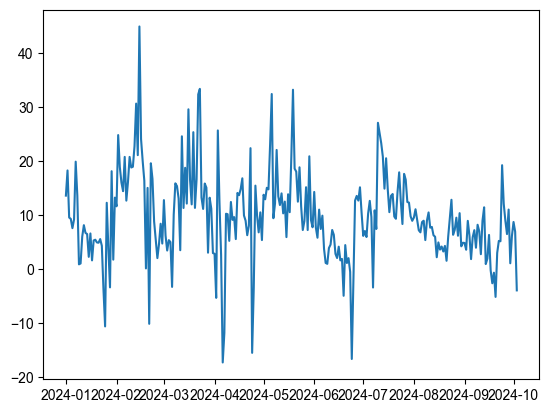

In [82]:
time_invertal = '1d'

heat_loss = heat_loss.resample(time_invertal).sum()
water = water.resample(time_invertal).mean()
tair = tair.resample(time_invertal).mean()

plt.plot(heat_loss.index, heat_loss.values)
plt.show()

## 3. functions for model


In [83]:
def calculate_error_statistics(trainy_true, trainy_pred, testy_true, testy_pred, model_name='Model'):
    if isinstance(trainy_pred, np.ndarray):
        trainy_pred_series = pd.Series(trainy_pred, index=trainy_true.index)
    else:
        trainy_pred_series = trainy_pred
    
    if isinstance(testy_pred, np.ndarray):
        testy_pred_series = pd.Series(testy_pred, index=testy_true.index)
    else:
        testy_pred_series = testy_pred
    
    # basic metrics
    train_r2 = r2_score(trainy_true.values, trainy_pred_series.values)
    test_r2 = r2_score(testy_true.values, testy_pred_series.values)
    train_rmse = np.sqrt(mean_squared_error(trainy_true.values, trainy_pred_series.values))
    test_rmse = np.sqrt(mean_squared_error(testy_true.values, testy_pred_series.values))
    train_mae = mean_absolute_error(trainy_true.values, trainy_pred_series.values)
    test_mae = mean_absolute_error(testy_true.values, testy_pred_series.values)
    
    # monthly value
    monthly_trainy_true = trainy_true.resample('ME').sum()
    monthly_trainy_pred = trainy_pred_series.resample('ME').sum()
    monthly_testy_true = testy_true.resample('ME').sum()
    monthly_testy_pred = testy_pred_series.resample('ME').sum()
    
    # annual value
    yearly_trainy_true = trainy_true.resample('YE').sum()
    yearly_trainy_pred = trainy_pred_series.resample('YE').sum()
    yearly_testy_true = testy_true.resample('YE').sum()
    yearly_testy_pred = testy_pred_series.resample('YE').sum()
    
    # monthly MAE
    monthly_mae_train = mean_absolute_error(monthly_trainy_true.values, monthly_trainy_pred.values)
    monthly_mae_test = mean_absolute_error(monthly_testy_true.values, monthly_testy_pred.values)
    
    # annual MAE
    yearly_monthly_mae_train = []
    for year in monthly_trainy_true.index.year.unique():
        year_mask = monthly_trainy_true.index.year == year
        year_true = monthly_trainy_true[year_mask]
        year_pred = monthly_trainy_pred[year_mask]
        if len(year_true) > 0:
            year_mae = mean_absolute_error(year_true.values, year_pred.values)
            yearly_monthly_mae_train.append((year, year_mae))
    
    yearly_monthly_mae_test = []
    for year in monthly_testy_true.index.year.unique():
        year_mask = monthly_testy_true.index.year == year
        year_true = monthly_testy_true[year_mask]
        year_pred = monthly_testy_pred[year_mask]
        if len(year_true) > 0:
            year_mae = mean_absolute_error(year_true.values, year_pred.values)
            yearly_monthly_mae_test.append((year, year_mae))
    
    # max monthly error
    yearly_max_monthly_mae_train = []
    for year in monthly_trainy_true.index.year.unique():
        year_mask = monthly_trainy_true.index.year == year
        year_true = monthly_trainy_true[year_mask]
        year_pred = monthly_trainy_pred[year_mask]
        if len(year_true) > 0:
            monthly_abs_errors = np.abs(year_true.values - year_pred.values)
            max_error_idx = np.argmax(monthly_abs_errors)
            max_error = monthly_abs_errors[max_error_idx]
            max_error_month = year_true.index[max_error_idx]
            yearly_max_monthly_mae_train.append((year, max_error, max_error_month))
    
    yearly_max_monthly_mae_test = []
    for year in monthly_testy_true.index.year.unique():
        year_mask = monthly_testy_true.index.year == year
        year_true = monthly_testy_true[year_mask]
        year_pred = monthly_testy_pred[year_mask]
        if len(year_true) > 0:
            monthly_abs_errors = np.abs(year_true.values - year_pred.values)
            max_error_idx = np.argmax(monthly_abs_errors)
            max_error = monthly_abs_errors[max_error_idx]
            max_error_month = year_true.index[max_error_idx]
            yearly_max_monthly_mae_test.append((year, max_error, max_error_month))
    
    # annual percentage error
    yearly_mae_train = []
    for year in yearly_trainy_true.index:
        true_val = yearly_trainy_true.loc[year]
        pred_val = yearly_trainy_pred.loc[year] if year in yearly_trainy_pred.index else 0
        mae = (pred_val - true_val)
        pct_dev = 100 * (pred_val - true_val) / true_val if true_val != 0 else 0
        yearly_mae_train.append((year, mae, pct_dev))
    
    yearly_mae_test = []
    for year in yearly_testy_true.index:
        true_val = yearly_testy_true.loc[year]
        pred_val = yearly_testy_pred.loc[year] if year in yearly_testy_pred.index else 0
        mae = (pred_val - true_val)
        pct_dev = 100 * (pred_val - true_val) / true_val if true_val != 0 else 0
        yearly_mae_test.append((year, mae, pct_dev))
    
    # 计算月度详细差异
    monthly_diffs_train = []
    for month in monthly_trainy_true.index:
        true_val = monthly_trainy_true.loc[month]
        pred_val = monthly_trainy_pred.loc[month] if month in monthly_trainy_pred.index else 0
        diff = pred_val - true_val
        pct_diff = 100 * diff / true_val if true_val != 0 else 0
        monthly_diffs_train.append((month, true_val, pred_val, diff, pct_diff))
    
    monthly_diffs_test = []
    for month in monthly_testy_true.index:
        true_val = monthly_testy_true.loc[month]
        pred_val = monthly_testy_pred.loc[month] if month in monthly_testy_pred.index else 0
        diff = pred_val - true_val
        pct_diff = 100 * diff / true_val if true_val != 0 else 0
        monthly_diffs_test.append((month, true_val, pred_val, diff, pct_diff))
    
    print(f'\n=== Yearly Monthly Data MAE ===')
    # 创建字典以便匹配年份
    train_max_dict = {year: (max_mae, max_month) for year, max_mae, max_month in yearly_max_monthly_mae_train}
    test_max_dict = {year: (max_mae, max_month) for year, max_mae, max_month in yearly_max_monthly_mae_test}
    
    print('Training Set:')
    for year, mae in yearly_monthly_mae_train:
        max_mae, max_month = train_max_dict.get(year, (None, None))
        print(f'  {year}: Average MAE={mae:.2f}, Max MAE={max_mae:.2f} (Month: {max_month.strftime("%Y-%m")})')

    print('Test Set:')
    for year, mae in yearly_monthly_mae_test:
        max_mae, max_month = test_max_dict.get(year, (None, None))
        print(f'  {year}: Average MAE={mae:.2f}, Max MAE={max_mae:.2f} (Month: {max_month.strftime("%Y-%m")})')

    print(f'\n=== Yearly Data MAE and Percentage Deviation ===')
    print('Training Set:')
    for year, mae, pct_dev in yearly_mae_train:
        print(f'  {year.strftime("%Y")}: MAE={mae:.2f}, Percentage Deviation={pct_dev:.2f}%')
    print('Test Set:')
    for year, mae, pct_dev in yearly_mae_test:
        print(f'  {year.strftime("%Y")}: MAE={mae:.2f}, Percentage Deviation={pct_dev:.2f}%')
    
    print(f'\n=== Detailed Monthly Differences ===')
    print('Training Set:')
    for month, true_val, pred_val, diff, pct_diff in monthly_diffs_train:
        print(f'  {month.strftime("%Y-%m")}: True={true_val:.2f}, Predicted={pred_val:.2f}, Diff={diff:.2f} ({pct_diff:.2f}%)')
    print('Test Set:')
    for month, true_val, pred_val, diff, pct_diff in monthly_diffs_test:
        print(f'  {month.strftime("%Y-%m")}: True={true_val:.2f}, Predicted={pred_val:.2f}, Diff={diff:.2f} ({pct_diff:.2f}%)')
    
    stats = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'monthly_mae_train': monthly_mae_train,
        'monthly_mae_test': monthly_mae_test,
        'yearly_monthly_mae_train': yearly_monthly_mae_train,
        'yearly_monthly_mae_test': yearly_monthly_mae_test,
        'yearly_max_monthly_mae_train': yearly_max_monthly_mae_train,
        'yearly_max_monthly_mae_test': yearly_max_monthly_mae_test,
        'yearly_mae_train': yearly_mae_train,
        'yearly_mae_test': yearly_mae_test,
        'monthly_diffs_train': monthly_diffs_train,
        'monthly_diffs_test': monthly_diffs_test,
        'monthly_trainy_true': monthly_trainy_true,
        'monthly_trainy_pred': monthly_trainy_pred,
        'monthly_testy_true': monthly_testy_true,
        'monthly_testy_pred': monthly_testy_pred,
        'yearly_trainy_true': yearly_trainy_true,
        'yearly_trainy_pred': yearly_trainy_pred,
        'yearly_testy_true': yearly_testy_true,
        'yearly_testy_pred': yearly_testy_pred
    }
    
    return stats

In [84]:
def plot_compare(testy_true, testy_pred):
    """
    Plot test data: time series, monthly difference, and monthly sums.
    testy_true: true values (Series or array), testy_pred: predicted (array or Series).
    """
    plt.rcParams['font.family'] = 'Arial'
    color_true = '#1363DF'
    color_pred = '#FF6600'
    color_diff_pos = '#1363DF'
    color_diff_neg = '#FF6600'

    if isinstance(testy_pred, np.ndarray):
        testy_pred_series = pd.Series(testy_pred, index=testy_true.index)
    else:
        testy_pred_series = testy_pred

    monthly_true = testy_true.resample('ME').sum()
    monthly_pred = testy_pred_series.resample('ME').sum()
    monthly_diff = monthly_pred.values - monthly_true.values

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

    # 1) Time series
    ax1.plot(testy_true.index, testy_true.values if hasattr(testy_true, 'values') else testy_true,
             label='True', linewidth=0.8, color=color_true)
    ax1.plot(testy_true.index, testy_pred, label='Predicted', linewidth=1, color=color_pred)
    ax1.set_ylabel('Heat Loss')
    ax1.set_xlabel('Time')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # 2) Monthly difference
    colors = [color_diff_pos if d >= 0 else color_diff_neg for d in monthly_diff]
    ax2.bar(monthly_true.index, monthly_diff, width=22, color=colors, edgecolor='white', linewidth=0.5)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax2.set_ylabel('Difference (Pred - True)')
    ax2.set_xlabel('Time')
    ax2.grid(True, alpha=0.3)

    # 3) Monthly sums
    w = 9
    ax3.bar(monthly_true.index - pd.Timedelta(days=w/2), monthly_true.values,
            width=w, label='True', color=color_true, edgecolor='navy', linewidth=0.5)
    ax3.bar(monthly_pred.index + pd.Timedelta(days=w/2), monthly_pred.values,
            width=w, label='Predicted', color=color_pred, edgecolor='darkorange', linewidth=0.5)
    ax3.set_ylabel('Monthly Sum')
    ax3.set_xlabel('Time')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. models

### 0. Configuration

In [85]:
# the area of the HojeTaastrup PTES
A_top = 11108
A_bot = 864
A_side = 10800
T_inf = 10
volumes = [
    2018.9, 2638.2, 2577.4, 2517.1, 2457.3, 4157.8, 4533.7, 4305.1, 4080.9,
    3860.9, 3645.3, 3434.0, 3227.0, 3024.1, 2826.8, 4482.8, 4426.1, 2403.9,
    1727.6, 1559.4, 3191.1, 1452.0, 763.63, 453.5, 607.3, 259.4]
area_side = np.array([218.96,289.32,286.31,283.29,280.26,483.09,540.66,528.36,
    515.96,503.43,490.79,478.01,465.06,451.90,438.74,735.06,787.39,462.43,352.38,
    336.25,764.20,399.83,231.52,147.20,212.50,97.81])
# divide the pit into two part 
A_side2 = np.array([np.sum(area_side[:10]),np.sum(area_side[10:])])

# ====== Parameter normalization / denormalization ======
def to_unit(x_real, lb, ub):
    """Map real parameters to [0, 1]: x_u = (x - lb) / (ub - lb)"""
    lb = np.asarray(lb, dtype=float)
    ub = np.asarray(ub, dtype=float)
    x_real = np.asarray(x_real, dtype=float)
    return (x_real - lb) / (ub - lb)

def to_real(x_unit, lb, ub):
    """Map [0, 1] parameters back to real range: x = lb + x_u * (ub - lb)"""
    lb = np.asarray(lb, dtype=float)
    ub = np.asarray(ub, dtype=float)
    x_unit = np.asarray(x_unit, dtype=float)
    return lb + x_unit * (ub - lb)

def clip_unit(x_unit):
    """Clip x_u to [0, 1] for numerical stability and to avoid float overflow."""
    return np.clip(np.asarray(x_unit, dtype=float), 0.0, 1.0)

### 5R2C

Optimization success: True
Estimated parameters:
  U_soil_s = 3.295e+00
  UA_s_inf = 4.720e+03
  UA_soilair = 2.447e+03
  U_top    = 1.179e-01
  U_topair = 8.639e+01
  C_s      = 5.803e+10
  C_top    = 7.864e+09
  Ts0      = 5.227e+01
  Tt0      = 5.619e+01

=== Yearly Monthly Data MAE ===
Training Set:
  2024: Average MAE=23.85, Max MAE=44.52 (Month: 2024-03)
Test Set:
  2024: Average MAE=25.00, Max MAE=44.52 (Month: 2024-03)

=== Yearly Data MAE and Percentage Deviation ===
Training Set:
  2024: MAE=6.94, Percentage Deviation=0.37%
Test Set:
  2024: MAE=113.78, Percentage Deviation=4.26%

=== Detailed Monthly Differences ===
Training Set:
  2024-01: True=202.13, Predicted=232.96, Diff=30.83 (15.25%)
  2024-02: True=448.92, Predicted=479.46, Diff=30.54 (6.80%)
  2024-03: True=416.59, Predicted=372.07, Diff=-44.52 (-10.69%)
  2024-04: True=215.23, Predicted=199.34, Diff=-15.90 (-7.39%)
  2024-05: True=457.67, Predicted=449.99, Diff=-7.68 (-1.68%)
  2024-06: True=143.68, Predicted=157.3

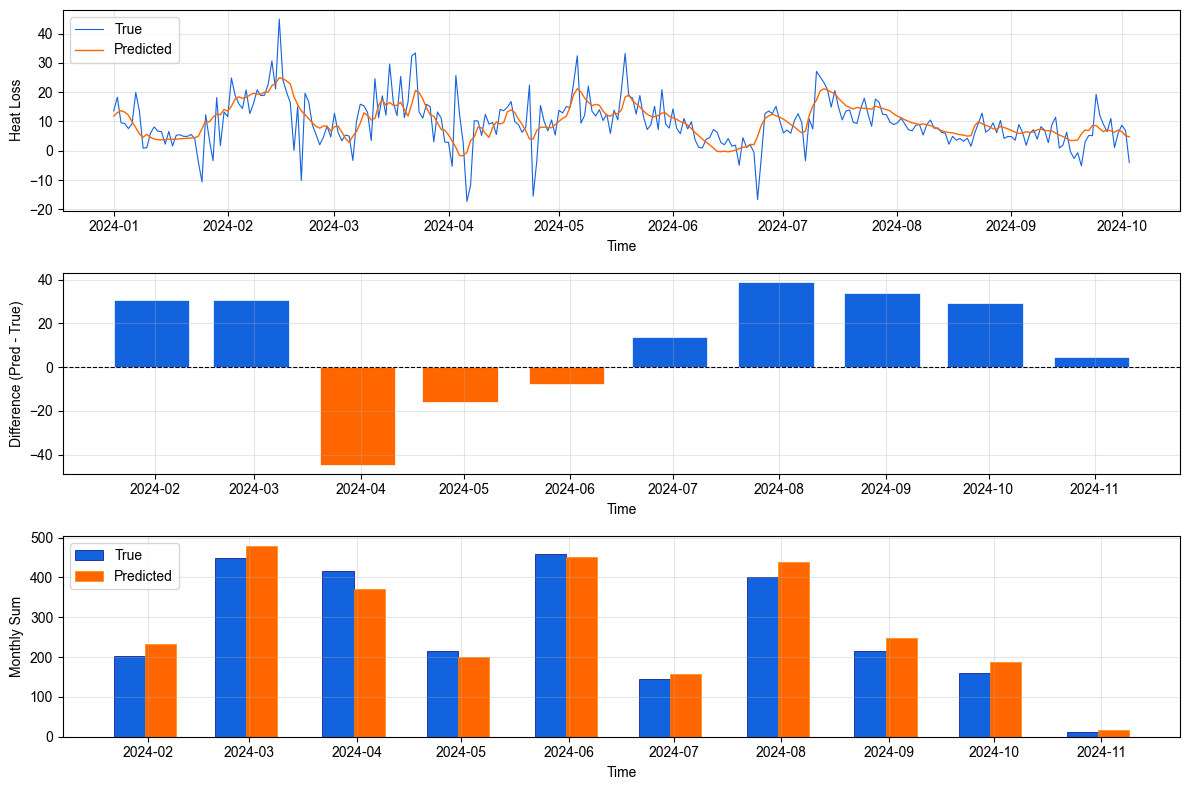

In [86]:
@jit(nopython=True)
def simulate_5R2C_numba(params, Ttop_vals, Tside_vals, Tair_vals, 
                         A_side, A_top, T_inf):
    # change the time step to seconds
    lam = 1*24*3600 
    U_soil_s, UA_s_inf, UA_soilair, U_top, U_topair, C_s, C_top, Ts0, Tt0 = params

    alpha_side = (U_soil_s * A_side) / C_s  
    beta_side  = (UA_s_inf) / C_s    
    theta_side = (UA_soilair) / C_s 

    alpha_top = (U_top * A_top) / C_top 
    beta_top  = (U_topair * A_top) / C_top 

    N = len(Tside_vals)
    T_s = np.zeros(N)
    T_t = np.zeros(N)
    T_s[0] = Ts0 
    T_t[0] = Tt0

    for k in range(N-1):
        numer = T_s[k] + lam*(alpha_side*Tside_vals[k] + beta_side*T_inf + theta_side*Tair_vals[k])
        denom = 1.0 + lam*(alpha_side + beta_side + theta_side)
        T_s[k+1] = numer / denom

        numer = T_t[k] + lam*(alpha_top*Ttop_vals[k] + beta_top*Tair_vals[k])
        denom = 1.0 + lam*(alpha_top + beta_top)
        T_t[k+1] = numer / denom

    Q_t = (U_top * A_top) * (Ttop_vals - T_t)
    Q_s = (U_soil_s * A_side) * (Tside_vals - T_s)
    Q = lam*(Q_t + Q_s) / 3.6e9
    
    return Q, T_t, T_s

def simulate_5R2C(params, Ttop, Tside, Tair):
    Ttop_vals = Ttop.values if hasattr(Ttop, 'values') else np.array(Ttop)
    Tside_vals = Tside.values if hasattr(Tside, 'values') else np.array(Tside)
    Tair_vals = Tair.values if hasattr(Tair, 'values') else np.array(Tair)
    
    Q, T_t, T_s = simulate_5R2C_numba(
        np.array(params, dtype=np.float64),
        Ttop_vals, Tside_vals, Tair_vals,
        A_side, A_top, T_inf)
    
    return pd.Series(Q, index=Tside.index), T_t, T_s

def objective(params_vec,  T_watertop,T_waterside,Tair,Q_obs):
    Q_total = simulate_5R2C(params_vec, T_watertop,T_waterside,Tair)[0]
    loss = np.mean((Q_total - Q_obs)**2)
    return loss


def objective_unit(params_unit, T_watertop,T_waterside,Tair,Q_obs, lb, ub):
    params_unit = clip_unit(params_unit)
    params_real = to_real(params_unit, lb, ub)
    return objective(params_real, T_watertop,T_waterside,Tair,Q_obs)


def state_variable_model(trainx, trainy, testx, testy):
    train_T_watertop = trainx['watertop']
    train_T_waterside = trainx['waterside']
    train_Tair = trainx['Tam']

    train_Q = trainy

    test_T_watertop = testx['watertop']
    test_T_waterside = testx['waterside']
    test_Tair = testx['Tam']
 
    bounds = [(0.01,100),      # U_soil
              (1e0,1e5),       # UA_s_inf
              (1e0,1e5),       # UA_soilair
              (0.01,100),      # U_top
              (0.01,100),      # U_topair
              (1e9,5e12),      # C_s
              (1e7,1e10),      # C_top
              (5,90),          # Ts0
              (5,90)]          # Tt0
 

    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]

    args = (train_T_watertop,train_T_waterside,train_Tair,train_Q)

    from scipy.optimize import differential_evolution
    bounds_unit = [(0.0, 1.0)] * len(bounds)
    model = differential_evolution(
        objective_unit,popsize=30,
        args=args + (lb, ub),
        bounds=bounds_unit, seed=42, disp=False
    )

    x_best_real = to_real(model.x, lb, ub)

    print("Optimization success:", model.success)
    print("Estimated parameters:")
    param_names = ['U_soil_s', 'UA_s_inf','UA_soilair', 'U_top','U_topair','C_s','C_top','Ts0','Tt0']
    for name, val in zip(param_names, x_best_real):
        print(f"  {name:8s} = {val:.3e}")

    train_pred,T_t, T_s= simulate_5R2C(x_best_real,train_T_watertop,train_T_waterside,train_Tair)
    test_pred,T_t,T_s= simulate_5R2C(x_best_real,test_T_watertop,test_T_waterside,test_Tair)

    calculate_error_statistics(trainy, train_pred, testy, test_pred, model_name='Model')
    plot_compare(testy, test_pred)

    results_df = pd.DataFrame({
    'observed': testy,
    'predicted': test_pred
    })
    # results_df.to_csv('5R2C.csv', index=True, index_label='datetime')


weighted_temp = water.mean(axis=1)
watertop = water['A_00.25m']
waterbot = water['A_13.80m']

water_input = pd.concat([watertop,waterbot,weighted_temp,tair],axis=1)
water_input.columns = ['watertop','waterbot','waterside','Tam']

trainx = water_input[(water_input.index< '2024-07-01')]
trainy = heat_loss[(heat_loss.index< '2024-07-01')] 

testx = water_input
testy = heat_loss

state_variable_model(trainx, trainy, testx, testy)

### 6R2C

Optimization success: True
Estimated parameters:
  U_s_soil = 3.131e+00
  U_b_soil = 8.094e+01
  UA_s_inf = 3.693e+03
  UA_soilair = 3.692e+03
  UA_b_inf = 2.926e+01
  U_top    = 1.055e-01
  C_s      = 6.907e+10
  C_b      = 7.470e+08
  Ts0      = 5.223e+01
  Tb0      = 4.807e+01

=== Yearly Monthly Data MAE ===
Training Set:
  2024: Average MAE=22.84, Max MAE=40.10 (Month: 2024-03)
Test Set:
  2024: Average MAE=21.34, Max MAE=40.10 (Month: 2024-03)

=== Yearly Data MAE and Percentage Deviation ===
Training Set:
  2024: MAE=10.46, Percentage Deviation=0.56%
Test Set:
  2024: MAE=86.82, Percentage Deviation=3.25%

=== Detailed Monthly Differences ===
Training Set:
  2024-01: True=202.13, Predicted=226.88, Diff=24.75 (12.24%)
  2024-02: True=448.92, Predicted=484.01, Diff=35.10 (7.82%)
  2024-03: True=416.59, Predicted=376.49, Diff=-40.10 (-9.63%)
  2024-04: True=215.23, Predicted=201.24, Diff=-13.99 (-6.50%)
  2024-05: True=457.67, Predicted=448.47, Diff=-9.19 (-2.01%)
  2024-06: True=1

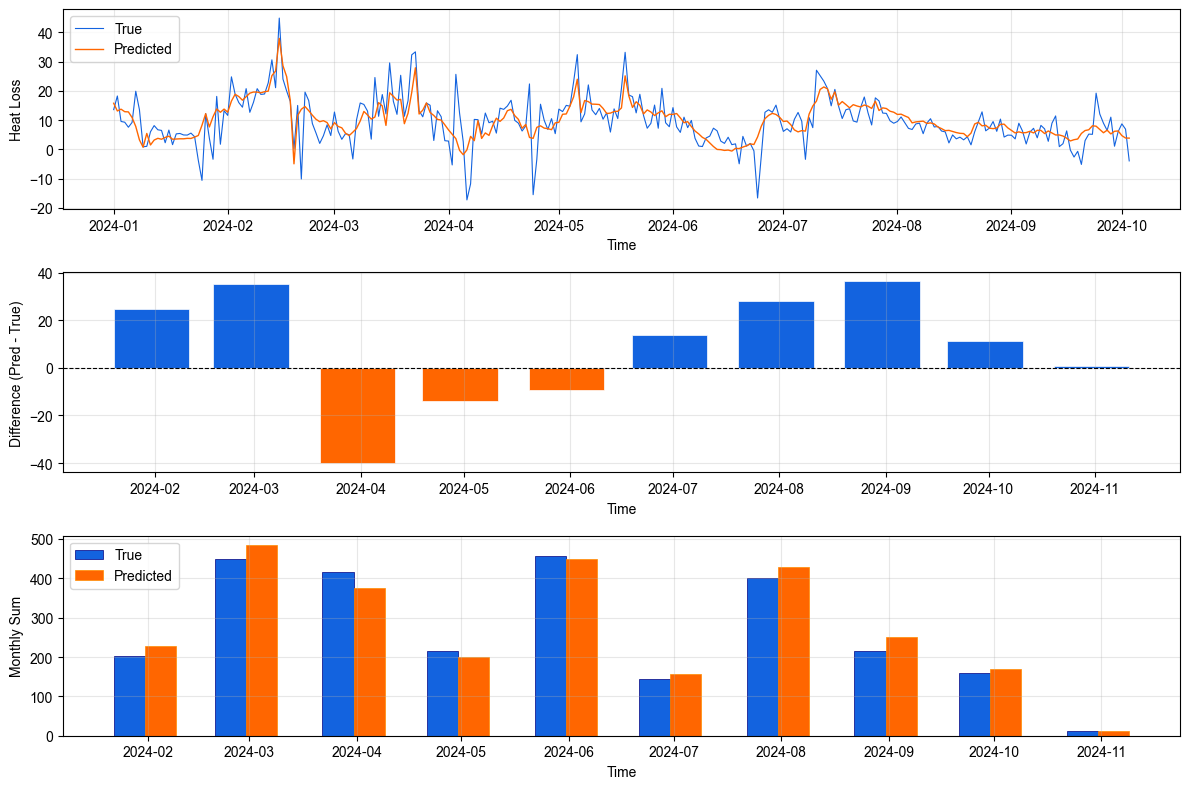

In [87]:
@jit(nopython=True)
def simulate_6R2C_numba(params, Ttop_vals, Tside_vals, Tbot_vals, Tair_vals, 
                          A_side, A_bot, A_top, T_inf):
    # change time interval to seconds
    lam = 24*3600   # 1d
    U_s_soil, U_b_soil, UA_s_inf, UA_soilair, UA_b_inf, U_top, C_s, C_b, Ts0, Tb0 = params

    alpha_side = (U_s_soil * A_side) / C_s  
    beta_side  = (UA_s_inf) / C_s 
    theta_side = (UA_soilair) / C_s

    alpha_bot = (U_b_soil * A_bot) / C_b  
    beta_bot  = (UA_b_inf) / C_b   

    N = len(Tside_vals)
    T_s = np.zeros(N)
    T_b = np.zeros(N)
    T_s[0] = Ts0 
    T_b[0] = Tb0

    for k in range(N-1):
        numer = T_s[k] + lam*(alpha_side*Tside_vals[k] + beta_side*T_inf + theta_side*Tair_vals[k])
        denom = 1.0 + lam*(alpha_side + beta_side + theta_side)
        T_s[k+1] = numer / denom

        numer = T_b[k] + lam*(alpha_bot*Tbot_vals[k] + beta_bot*T_inf)
        denom = 1.0 + lam*(alpha_bot + beta_bot)
        T_b[k+1] = numer / denom

    Q_b = (U_b_soil * A_bot) * (Tbot_vals - T_b)
    Q_t = (U_top * A_top) * (Ttop_vals - Tair_vals) 
    Q_s = (U_s_soil * A_side) * (Tside_vals - T_s)
    Q = lam*(Q_b + Q_t + Q_s) / 3.6e9
    
    return Q, T_s, T_b

def simulate_6R2C(params, Ttop, Tside, Tbot, Tair):
    params_array = np.array(params, dtype=np.float64)

    Ttop_vals = Ttop.values if hasattr(Ttop, 'values') else np.array(Ttop)
    Tside_vals = Tside.values if hasattr(Tside, 'values') else np.array(Tside)
    Tbot_vals = Tbot.values if hasattr(Tbot, 'values') else np.array(Tbot)
    Tair_vals = Tair.values if hasattr(Tair, 'values') else np.array(Tair)

    Q, T_s, T_b = simulate_6R2C_numba(
        params_array,
        Ttop_vals, Tside_vals, Tbot_vals, Tair_vals,
        A_side,A_bot,A_top,T_inf)
    
    return pd.Series(Q, index=Tside.index), T_s, T_b

def objective(params_vec, T_watertop, T_waterside, T_waterbot, Tair, Q_obs):
    Q_total, T_s, T_b = simulate_6R2C(params_vec, T_watertop, T_waterside, T_waterbot, Tair)
    loss = np.mean((Q_total - Q_obs)**2)
    return loss


def objective_unit(params_unit, T_watertop, T_waterside, T_waterbot, Tair, Q_obs, lb, ub):
    params_unit = clip_unit(params_unit)
    params_real = to_real(params_unit, lb, ub)
    return objective(params_real, T_watertop, T_waterside, T_waterbot, Tair, Q_obs)


def state_variable_model(trainx, trainy, testx, testy):
    train_T_watertop = trainx['watertop']
    train_T_waterside = trainx['waterside']
    train_T_waterbot = trainx['waterbot']
    train_Tair = trainx['Tam']
    train_Q = trainy

    test_T_watertop = testx['watertop']
    test_T_waterside = testx['waterside']
    test_T_waterbot = testx['waterbot']
    test_Tair = testx['Tam']
    
    bounds = [(0.01,100),     # U_s_soil
              (0.01,100),     # U_b_soil
              (1e0,1e5),      # UA_s_inf
              (1e0,1e5),      # UA_soilair
              (1e0,1e5),      # UA_b_inf
              (0.01,100),     # U_top
              (1e9,5e12),     # C_s
              (1e8,5e11),     # C_b
              (5,90),         # Ts0
              (5,90)]         # Tb0
              
    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]

    args = (train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair, train_Q)
    from scipy.optimize import differential_evolution

    bounds_unit = [(0.0, 1.0)] * len(bounds)
    model = differential_evolution(
        objective_unit, popsize=30,
        args=args + (lb, ub), maxiter=500,
        bounds=bounds_unit, seed=42, disp=False
    )

    x_best_real = to_real(model.x, lb, ub)

    print("Optimization success:", model.success)
    print("Estimated parameters:")
    param_names = ['U_s_soil', 'U_b_soil','UA_s_inf','UA_soilair','UA_b_inf', 'U_top','C_s','C_b','Ts0','Tb0']
    for name, val in zip(param_names, x_best_real):
        print(f"  {name:8s} = {val:.3e}")

    train_pred, T_s, T_b = simulate_6R2C(x_best_real, train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair)
    test_pred, T_s, T_b = simulate_6R2C(x_best_real, test_T_watertop, test_T_waterside, test_T_waterbot, test_Tair)

    calculate_error_statistics(trainy, train_pred, testy, test_pred, model_name='Model')
    plot_compare(testy, test_pred)

    results_df = pd.DataFrame({
        'observed': testy,
        'predicted': test_pred
    })
    # results_df.to_csv('6R2C.csv', index=True, index_label='datetime')

# load data and split it into training set and testing set
weighted_temp = water.mean(axis=1)
watertop = water['A_00.25m']
waterbot = water['A_13.80m']

water_input = pd.concat([watertop,waterbot,weighted_temp,tair],axis=1)
water_input.columns = ['watertop','waterbot','waterside','Tam']

trainx = water_input[(water_input.index< '2024-07-01')]
trainy = heat_loss[(heat_loss.index< '2024-07-01')] 

testx = water_input
testy = heat_loss

state_variable_model(trainx, trainy, testx, testy)

### 7R3C (includes different loss functions)

Optimization success: True
Estimated parameters:
  U_soil_s = 3.10084e+00
  U_soil_b = 8.34467e+01
  UA_s_inf = 3.40240e+03
  UA_soilair = 2.37020e+03
  UA_b_inf = 1.00000e+00
  U_top    = 1.83345e-01
  U_topair = 8.53304e+01
  C_s      = 6.91718e+10
  C_b      = 6.43827e+08
  C_top    = 4.30218e+09
  Ts0      = 5.39480e+01
  Tb0      = 4.78020e+01
  Tt0      = 5.58215e+01

=== Yearly Monthly Data MAE ===
Training Set:
  2024: Average MAE=22.34, Max MAE=39.46 (Month: 2024-03)
Test Set:
  2024: Average MAE=21.08, Max MAE=39.46 (Month: 2024-03)

=== Yearly Data MAE and Percentage Deviation ===
Training Set:
  2024: MAE=5.37, Percentage Deviation=0.28%
Test Set:
  2024: MAE=82.11, Percentage Deviation=3.07%

=== Detailed Monthly Differences ===
Training Set:
  2024-01: True=202.13, Predicted=222.98, Diff=20.85 (10.32%)
  2024-02: True=448.92, Predicted=486.65, Diff=37.74 (8.41%)
  2024-03: True=416.59, Predicted=377.13, Diff=-39.46 (-9.47%)
  2024-04: True=215.23, Predicted=201.12, Diff=-

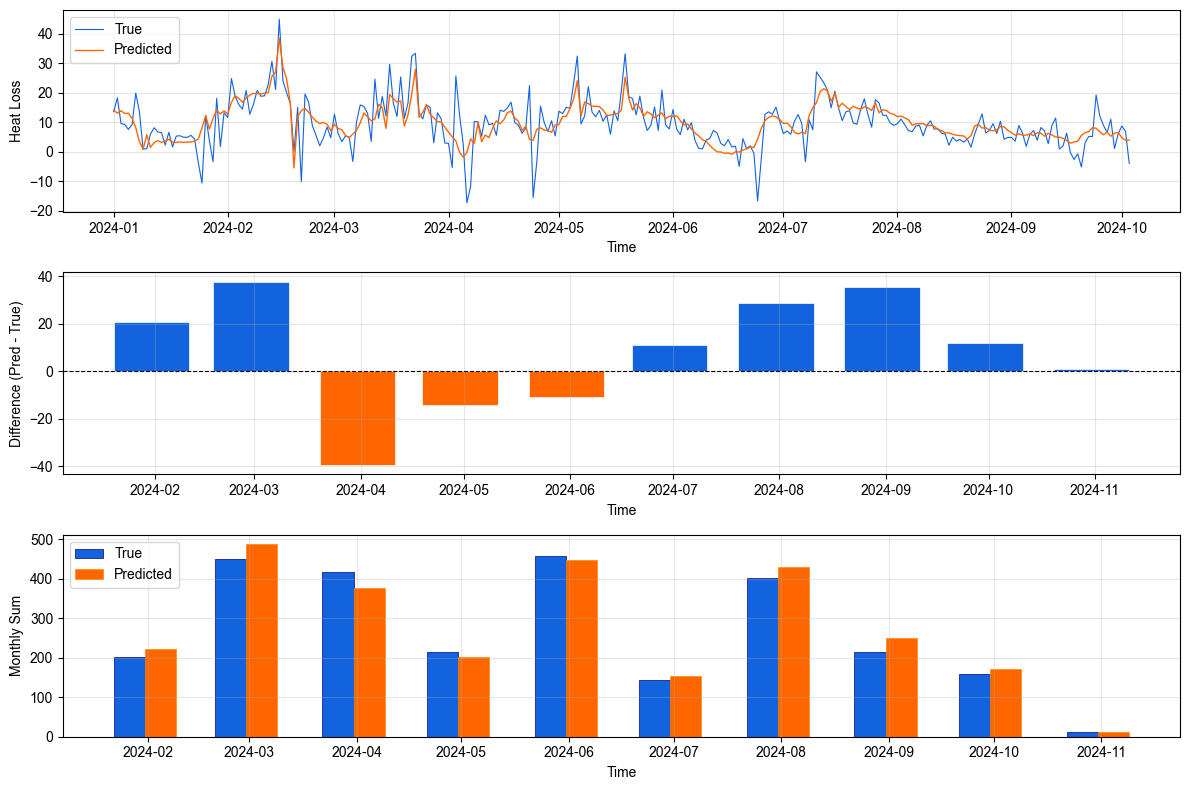

In [88]:
@jit(nopython=True)
def simulate_7R3C_numba(params, Ttop_vals, Tside_vals, Tbot_vals, Tair_vals, 
                          A_side, A_bot, A_top, T_inf):
    # change the time step to seconds
    lam = 1*24*3600 
    U_soil_s, U_soil_b, UA_s_inf, UA_soilair, UA_b_inf, U_top, U_topair, C_s, C_b, C_top, Ts0, Tb0, Tt0 = params
    
    alpha_side = (U_soil_s * A_side) / C_s  
    beta_side  = (UA_s_inf) / C_s    
    theta_side = (UA_soilair) / C_s 

    alpha_bot = (U_soil_b * A_bot) / C_b  
    beta_bot  = (UA_b_inf) / C_b   

    alpha_top = (U_top * A_top) / C_top 
    beta_top  = (U_topair * A_top) / C_top 

    N = len(Tside_vals)
    T_s = np.zeros(N)
    T_b = np.zeros(N)
    T_t = np.zeros(N)
    T_s[0] = Ts0 
    T_b[0] = Tb0
    T_t[0] = Tt0

    for k in range(N-1):
        numer = T_s[k] + lam*(alpha_side*Tside_vals[k] + beta_side*T_inf + theta_side*Tair_vals[k])
        denom = 1.0 + lam*(alpha_side + beta_side + theta_side)
        T_s[k+1] = numer / denom

        numer = T_b[k] + lam*(alpha_bot*Tbot_vals[k] + beta_bot*T_inf)
        denom = 1.0 + lam*(alpha_bot + beta_bot)
        T_b[k+1] = numer / denom

        numer = T_t[k] + lam*(alpha_top*Ttop_vals[k] + beta_top*Tair_vals[k])
        denom = 1.0 + lam*(alpha_top + beta_top)
        T_t[k+1] = numer / denom

    Q_b = (U_soil_b * A_bot) * (Tbot_vals - T_b)  # W
    Q_t = (U_top * A_top) * (Ttop_vals - T_t)
    Q_s = (U_soil_s * A_side) * (Tside_vals - T_s)
    Q = lam*(Q_b + Q_t + Q_s) / 3.6e9
    
    return Q, T_t, T_s, T_b

def simulate_7R3C(params, Ttop, Tside, Tbot, Tair):
    params_array = np.array(params, dtype=np.float64)
    
    Ttop_vals = Ttop.values if hasattr(Ttop, 'values') else np.array(Ttop)
    Tside_vals = Tside.values if hasattr(Tside, 'values') else np.array(Tside)
    Tbot_vals = Tbot.values if hasattr(Tbot, 'values') else np.array(Tbot)
    Tair_vals = Tair.values if hasattr(Tair, 'values') else np.array(Tair)

    Q, T_t, T_s, T_b = simulate_7R3C_numba(
        params_array,
        Ttop_vals, Tside_vals, Tbot_vals, Tair_vals,
        A_side, A_bot, A_top, T_inf
    )
    
    return pd.Series(Q, index=Tside.index), T_t, T_s, T_b

def objective(params_vec, T_watertop, T_waterside, T_waterbot, Tair, Q_obs, loss_type='mse'):

    Q_total = simulate_7R3C(params_vec, T_watertop, T_waterside, T_waterbot, Tair)[0]
    
    if loss_type == 'mse':
        loss = np.mean((Q_total - Q_obs)**2)
    
    elif loss_type == 'huber':
        delta = 10.0 
        error = Q_total - Q_obs
        abs_error = np.abs(error)
        loss = np.where(
            abs_error <= delta,
            0.5 * error**2,
            delta * (abs_error - 0.5 * delta))
        loss = np.mean(loss)

    elif loss_type == 'cumulativemse':
        loss = np.mean((Q_total.cumsum() - Q_obs.cumsum())**2)
    
    elif loss_type == '15windowmse':
        window_size = 15
        Q_total_rolling = Q_total.rolling(window=window_size, min_periods=window_size).sum()
        Q_obs_rolling = Q_obs.rolling(window=window_size, min_periods=window_size).sum()
        valid_mask = ~(Q_total_rolling.isna() | Q_obs_rolling.isna())
        if valid_mask.sum() > 0:
            loss = np.mean((Q_total_rolling[valid_mask] - Q_obs_rolling[valid_mask])**2)
        else:
            loss = 0
    
    elif loss_type == '30windowmse':
        window_size = 30
        Q_total_rolling = Q_total.rolling(window=window_size, min_periods=window_size).sum()
        Q_obs_rolling = Q_obs.rolling(window=window_size, min_periods=window_size).sum()
        valid_mask = ~(Q_total_rolling.isna() | Q_obs_rolling.isna())
        if valid_mask.sum() > 0:
            loss = np.mean((Q_total_rolling[valid_mask] - Q_obs_rolling[valid_mask])**2)
        else:
            loss = 0
    
    elif loss_type == 'mse+15windowmse':
        mse = np.mean((Q_total - Q_obs)**2)
        window_size = 15
        Q_total_rolling = Q_total.rolling(window=window_size, min_periods=window_size).sum()
        Q_obs_rolling = Q_obs.rolling(window=window_size, min_periods=window_size).sum()
        valid_mask = ~(Q_total_rolling.isna() | Q_obs_rolling.isna())
        if valid_mask.sum() > 0:
            loss_window = np.mean((Q_total_rolling[valid_mask] - Q_obs_rolling[valid_mask])**2)
        else:
            loss_window = 0
        loss = mse + loss_window
    
    elif loss_type == 'mse+0.5_15windowmse':
        mse = np.mean((Q_total - Q_obs)**2)
        window_size = 15
        Q_total_rolling = Q_total.rolling(window=window_size, min_periods=window_size).sum()
        Q_obs_rolling = Q_obs.rolling(window=window_size, min_periods=window_size).sum()
        valid_mask = ~(Q_total_rolling.isna() | Q_obs_rolling.isna())
        if valid_mask.sum() > 0:
            loss_window = np.mean((Q_total_rolling[valid_mask] - Q_obs_rolling[valid_mask])**2)
        else:
            loss_window = 0
        loss = mse + 0.5 * loss_window
    
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}. Supported types: 'mse', 'cumulative_mse', '15window', '30window', 'mse+15window', 'mse+0.5_15window'")
    
    return loss


def objective_unit(params_unit, T_watertop, T_waterside, T_waterbot, Tair, Q_obs, lb, ub, loss_type='mse'):
    params_unit = clip_unit(params_unit)
    params_real = to_real(params_unit, lb, ub)
    return objective(params_real, T_watertop, T_waterside, T_waterbot, Tair, Q_obs, loss_type)


def state_variable_model(trainx, trainy, testx, testy, loss_type='mse'):
    train_T_watertop = trainx['watertop']
    train_T_waterside = trainx['waterside']
    train_T_waterbot = trainx['waterbot']
    train_Tair = trainx['Tam']

    train_Q = trainy

    test_T_watertop = testx['watertop']
    test_T_waterside = testx['waterside']
    test_T_waterbot = testx['waterbot']
    test_Tair = testx['Tam']

    bounds = [(0.01,100),     # U_soil_s
              (0.01,100),     # U_soil_b
              (1e0,1e5),      # UA_s_inf
              (1e0,1e5),      # UA_soilair
              (1e0,1e5),      # UA_b_inf
              (0.01,100),     # U_top
              (0.01,100),     # U_topair
              (1e9,5e12),     # C_s
              (1e8,5e11),     # C_b
              (1e7,1e10),     # C_top
              (5,90),         # Ts0
              (5,90),         # Tb0
              (5,90)]         # Tt0


    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]

    args = (train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair, train_Q)
    bounds_unit = [(0.0, 1.0)] * len(bounds)
    model = differential_evolution(
        objective_unit, popsize=30, 
        args=args + (lb, ub, loss_type), maxiter=500,
        bounds=bounds_unit, seed=42, disp=False,)

    x_best_real = to_real(model.x, lb, ub)

    print("Optimization success:", model.success)
    print("Estimated parameters:")
    param_names = ['U_soil_s','U_soil_b', 'UA_s_inf', 'UA_soilair', 'UA_b_inf','U_top','U_topair','C_s','C_b','C_top','Ts0','Tb0','Tt0']
    for name, val in zip(param_names, x_best_real):
        print(f"  {name:8s} = {val:.5e}")

    train_pred, T_t, T_s, T_b = simulate_7R3C(x_best_real, train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair)
    test_pred, T_t, T_s, T_b = simulate_7R3C(x_best_real, test_T_watertop, test_T_waterside, test_T_waterbot, test_Tair)

    calculate_error_statistics(trainy, train_pred, testy, test_pred, model_name='Model')
    plot_compare(testy, test_pred)

    results_df = pd.DataFrame({
        'observed': testy,
        'predicted': test_pred
    })
    # results_df.to_csv(f'7R3C.csv', index=True, index_label='datetime')

# load data and split it into training set and testing set
weighted_temp = water.mean(axis=1)
watertop = water['A_00.25m']
waterbot = water['A_13.80m']

water_input = pd.concat([watertop,waterbot,weighted_temp,tair],axis=1)
water_input.columns = ['watertop','waterbot','waterside','Tam']

trainx = water_input[(water_input.index< '2024-07-01')]
trainy = heat_loss[(heat_loss.index< '2024-07-01')] 

testx = water_input
testy = heat_loss

state_variable_model(trainx, trainy, testx, testy, loss_type='mse')


### 10R4C

Optimization success: True
Estimated parameters:
  U_soil_s1 = 2.683e+00
  U_soil_s2 = 2.390e+00
  U_soil_b = 2.952e+01
  UA_s_inf1 = 1.433e+04
  UA_s_inf2 = 4.526e+04
  UA_soilair = 3.225e+04
  UA_side  = 7.365e+04
  UA_b_inf = 2.707e+00
  U_top    = 1.612e-01
  U_topair = 1.140e+00
  C_top    = 4.920e+09
  C_s1     = 4.074e+12
  C_s2     = 3.325e+12
  C_b      = 2.791e+11
  Tt0      = 8.297e+01
  Ts1      = 6.320e+01
  Ts2      = 8.781e+01
  Tb0      = 1.721e+01

=== Yearly Monthly Data MAE ===
Training Set:
  2024: Average MAE=30.41, Max MAE=54.11 (Month: 2024-02)
Test Set:
  2024: Average MAE=34.33, Max MAE=123.77 (Month: 2024-08)

=== Yearly Data MAE and Percentage Deviation ===
Training Set:
  2024: MAE=1.65, Percentage Deviation=0.09%
Test Set:
  2024: MAE=152.44, Percentage Deviation=5.71%

=== Detailed Monthly Differences ===
Training Set:
  2024-01: True=202.13, Predicted=198.35, Diff=-3.78 (-1.87%)
  2024-02: True=448.92, Predicted=503.02, Diff=54.11 (12.05%)
  2024-03: True

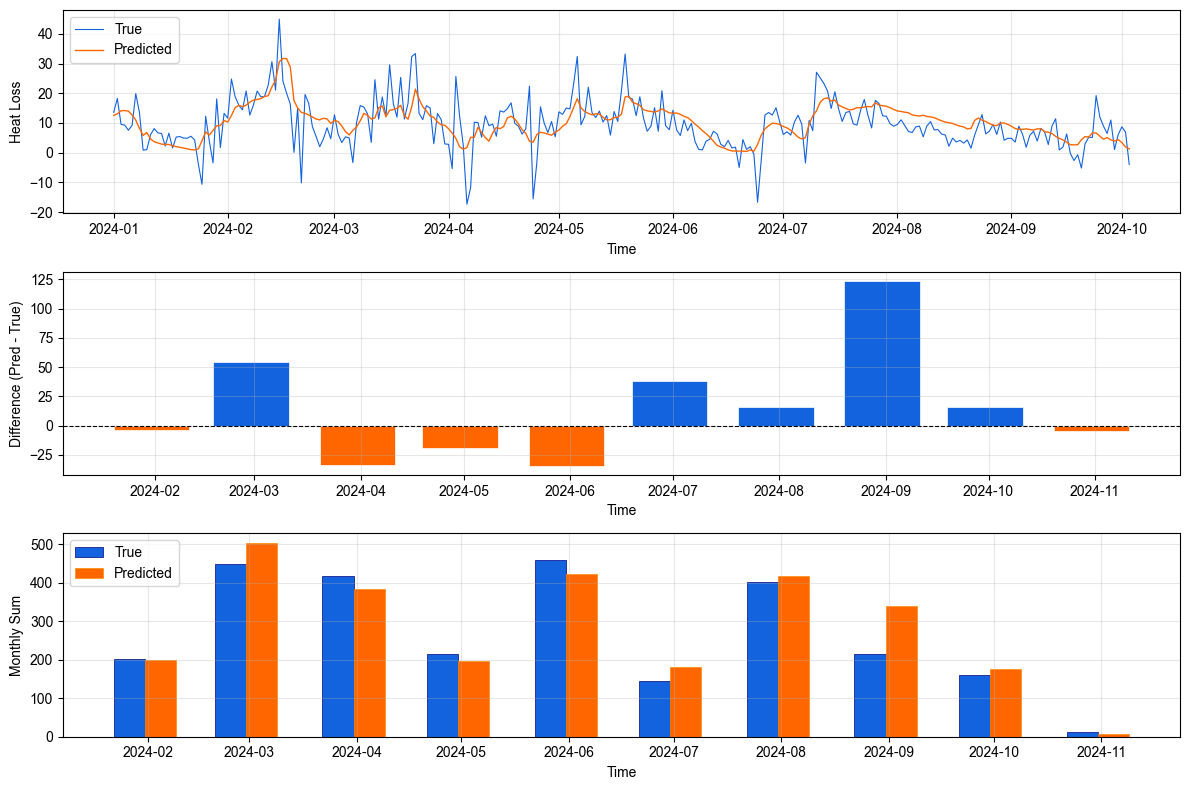

In [89]:
@jit(nopython=True)
def simulate_10R4C_numba(params, Ttop_vals, Tside1_vals, Tside2_vals, Tbot_vals, Tair_vals, 
                          A_side2_0, A_side2_1, A_bot, A_top, T_inf):
    lam = 24*3600   # 1d
    U_soil_s1, U_soil_s2, U_soil_b, UA_s_inf1, UA_s_inf2, UA_soilair, UA_side, UA_b_inf, \
    U_top, U_topair, C_top, C_s1, C_s2, C_b, Tt0, Ts1, Ts2, Tb0 = params

    alpha_side1 = (U_soil_s1 * A_side2_0) / C_s1
    beta_side1  = (UA_s_inf1) / C_s1
    theta_side1 = (UA_soilair) / C_s1
    gamma_side1 = (UA_side) / C_s1

    alpha_side2 = (U_soil_s2 * A_side2_1) / C_s2  
    beta_side2  = (UA_s_inf2) / C_s2 
    gamma_side2 = (UA_side) / C_s2

    alpha_bot = (U_soil_b * A_bot) / C_b  
    beta_bot  = (UA_b_inf) / C_b   

    alpha_top = (U_top * A_top) / C_top 
    beta_top  = (U_topair * A_top) / C_top 

    N = len(Tside1_vals)
    T_t = np.zeros(N)
    T_s1 = np.zeros(N)
    T_s2 = np.zeros(N)
    T_b = np.zeros(N)
    T_t[0] = Tt0
    T_s1[0] = Ts1 
    T_s2[0] = Ts2
    T_b[0] = Tb0

    for k in range(N-1):
        numer = T_s1[k] + lam*(alpha_side1*Tside1_vals[k] + beta_side1*T_inf + theta_side1*Tair_vals[k] + gamma_side1*T_s2[k])
        denom = 1.0 + lam*(alpha_side1 + beta_side1 + theta_side1 + gamma_side1)
        T_s1[k+1] = numer / denom

        numer = T_s2[k] + lam*(alpha_side2*Tside2_vals[k] + beta_side2*T_inf + gamma_side2*T_s1[k])
        denom = 1.0 + lam*(alpha_side2 + beta_side2 + gamma_side2)
        T_s2[k+1] = numer / denom

        numer = T_b[k] + lam*(alpha_bot*Tbot_vals[k+1] + beta_bot*T_inf)
        denom = 1.0 + lam*(alpha_bot + beta_bot)
        T_b[k+1] = numer / denom

        numer = T_t[k] + lam*(alpha_top*Ttop_vals[k+1] + beta_top*Tair_vals[k+1])
        denom = 1.0 + lam*(alpha_top + beta_top)
        T_t[k+1] = numer / denom

    Q_t = (U_top * A_top) * (Ttop_vals - T_t)
    Q_b = (U_soil_b * A_bot) * (Tbot_vals - T_b)
    Q_s1 = (U_soil_s1 * A_side2_0) * (Tside1_vals - T_s1)
    Q_s2 = (U_soil_s2 * A_side2_1) * (Tside2_vals - T_s2)
    Q = lam*(Q_b + Q_t + Q_s1 + Q_s2) / 3.6e9
    
    return Q, T_t, T_s1, T_s2, T_b

def simulate_10R4C(params, Ttop, Tside1, Tside2, Tbot, Tair):
    params_array = np.array(params, dtype=np.float64)
    
    Ttop_vals = Ttop.values if hasattr(Ttop, 'values') else np.array(Ttop)
    Tside1_vals = Tside1.values if hasattr(Tside1, 'values') else np.array(Tside1)
    Tside2_vals = Tside2.values if hasattr(Tside2, 'values') else np.array(Tside2)
    Tbot_vals = Tbot.values if hasattr(Tbot, 'values') else np.array(Tbot)
    Tair_vals = Tair.values if hasattr(Tair, 'values') else np.array(Tair)
    
    Q, T_t, T_s1, T_s2, T_b = simulate_10R4C_numba(
        params_array,
        Ttop_vals, Tside1_vals, Tside2_vals, Tbot_vals, Tair_vals,
        A_side2[0],
        A_side2[1], 
        A_bot,
        A_top,
        T_inf
    )

    return pd.Series(Q, index=Tside1.index), T_t, T_s1, T_s2, T_b

def objective(params_vec, T_watertop, T_waterside1, T_waterside2, T_waterbot, Tair, Q_obs):
    Q_total = simulate_10R4C(params_vec, T_watertop, T_waterside1, T_waterside2, T_waterbot, Tair)[0]
    loss = np.mean((Q_total - Q_obs)**2)
    return loss

def objective_unit(params_unit, T_watertop, T_waterside1, T_waterside2, T_waterbot, Tair, Q_obs, lb, ub):
    params_unit = clip_unit(params_unit)
    params_real = to_real(params_unit, lb, ub)
    return objective(params_real, T_watertop, T_waterside1, T_waterside2, T_waterbot, Tair, Q_obs)


def state_variable_model(trainx, trainy, testx, testy):
    train_T_watertop = trainx['watertop']
    train_T_waterside1 = trainx['waterside1']
    train_T_waterside2 = trainx['waterside2']
    train_T_waterbot = trainx['waterbot']
    train_Tair = trainx['Tam']

    train_Q = trainy

    test_T_watertop = testx['watertop']
    test_T_waterside1 = testx['waterside1']
    test_T_waterside2 = testx['waterside2']
    test_T_waterbot = testx['waterbot']
    test_Tair = testx['Tam']

    bounds = [(0.01,100),     # U_soil_s1 
              (0.01,100),     # U_soil_s2 
              (0.01,100),     # U_soil_b 
              (1e0,1e5),      # UA_s_inf1
              (1e0,1e5),      # UA_s_inf2
              (1e0,1e5),      # UA_soilair
              (1e0,1e5),      # UA_side
              (1e0,1e5),      # UA_b_inf
              (0.01,100),     # U_top
              (0.01,100),     # U_topair
              (1e7,1e10),     # C_top
              (1e9,5e12),     # C_s1
              (1e9,5e12),     # C_s2
              (1e8,5e11),     # C_b
              (5,90),         # Tt0
              (5,90),         # Ts1
              (5,90),         # Ts2
              (5,90)]         # Tb0
              

    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]

    args = (train_T_watertop, train_T_waterside1, train_T_waterside2, train_T_waterbot, train_Tair, train_Q)

    bounds_unit = [(0.0, 1.0)] * len(bounds)

    model = differential_evolution(
        objective_unit, popsize=30,
        args=args + (lb, ub), maxiter=500,
        bounds=bounds_unit, seed=42, disp=False
    )

    x_best_real = to_real(model.x, lb, ub)

    print("Optimization success:", model.success)
    print("Estimated parameters:")
    param_names = ['U_soil_s1', 'U_soil_s2','U_soil_b','UA_s_inf1', 'UA_s_inf2','UA_soilair','UA_side','UA_b_inf', 
    'U_top','U_topair','C_top','C_s1','C_s2','C_b','Tt0','Ts1','Ts2','Tb0']
    for name, val in zip(param_names, x_best_real):
        print(f"  {name:8s} = {val:.3e}")

    train_pred, T_t, T_s1, T_s2, T_b = simulate_10R4C(x_best_real, train_T_watertop, train_T_waterside1, train_T_waterside2, train_T_waterbot, train_Tair)
    test_pred, T_t, T_s1, T_s2, T_b = simulate_10R4C(x_best_real, test_T_watertop, test_T_waterside1, test_T_waterside2, test_T_waterbot, test_Tair)

    calculate_error_statistics(trainy, train_pred, testy, test_pred, model_name='Model')
    plot_compare(testy, test_pred)

    results_df = pd.DataFrame({
        'observed': testy,
        'predicted': test_pred
    })
    # results_df.to_csv('10R4C.csv', index=True, index_label='datetime')


waterside1 = water.iloc[:,:9].mean(axis=1)
waterside2 = water.iloc[:,9:].mean(axis=1)
watertop = water['A_00.25m']
waterbot = water['A_13.80m']

water_input = pd.concat([watertop,waterbot,waterside1,waterside2,tair],axis=1)
water_input.columns = ['watertop','waterbot','waterside1','waterside2','Tam']

trainx = water_input[(water_input.index< '2024-07-01')]
trainy = heat_loss[(heat_loss.index< '2024-07-01')] 

testx = water_input
testy = heat_loss

state_variable_model(trainx, trainy, testx, testy)

### 10R5C

Optimization success: True
Estimated parameters:
  U_soil_s = 3.717e+00
  U_soil_b = 8.966e+01
  UA_s_inf1 = 2.482e+04
  UA_s_inf2 = 1.102e+03
  UA_soilair1 = 2.435e+04
  UA_soilair2 = 8.822e+03
  UA_b_inf1 = 2.291e+01
  UA_b_inf2 = 3.466e+04
  U_top    = 4.194e-02
  U_topair = 2.735e+01
  C_top    = 3.898e+09
  C_s1     = 5.402e+10
  C_s2     = 4.051e+12
  C_b1     = 8.377e+09
  C_b2     = 4.184e+11
  Tt0      = 3.226e+01
  Ts1      = 4.783e+01
  Ts2      = 8.944e+01
  Tb1      = 5.242e+01
  Tb2      = 7.556e+01

=== Yearly Monthly Data MAE ===
Training Set:
  2024: Average MAE=10.35, Max MAE=18.25 (Month: 2024-01)
Test Set:
  2024: Average MAE=11.68, Max MAE=46.15 (Month: 2024-08)

=== Yearly Data MAE and Percentage Deviation ===
Training Set:
  2024: MAE=2.65, Percentage Deviation=0.14%
Test Set:
  2024: MAE=42.47, Percentage Deviation=1.59%

=== Detailed Monthly Differences ===
Training Set:
  2024-01: True=202.13, Predicted=220.38, Diff=18.25 (9.03%)
  2024-02: True=448.92, Predic

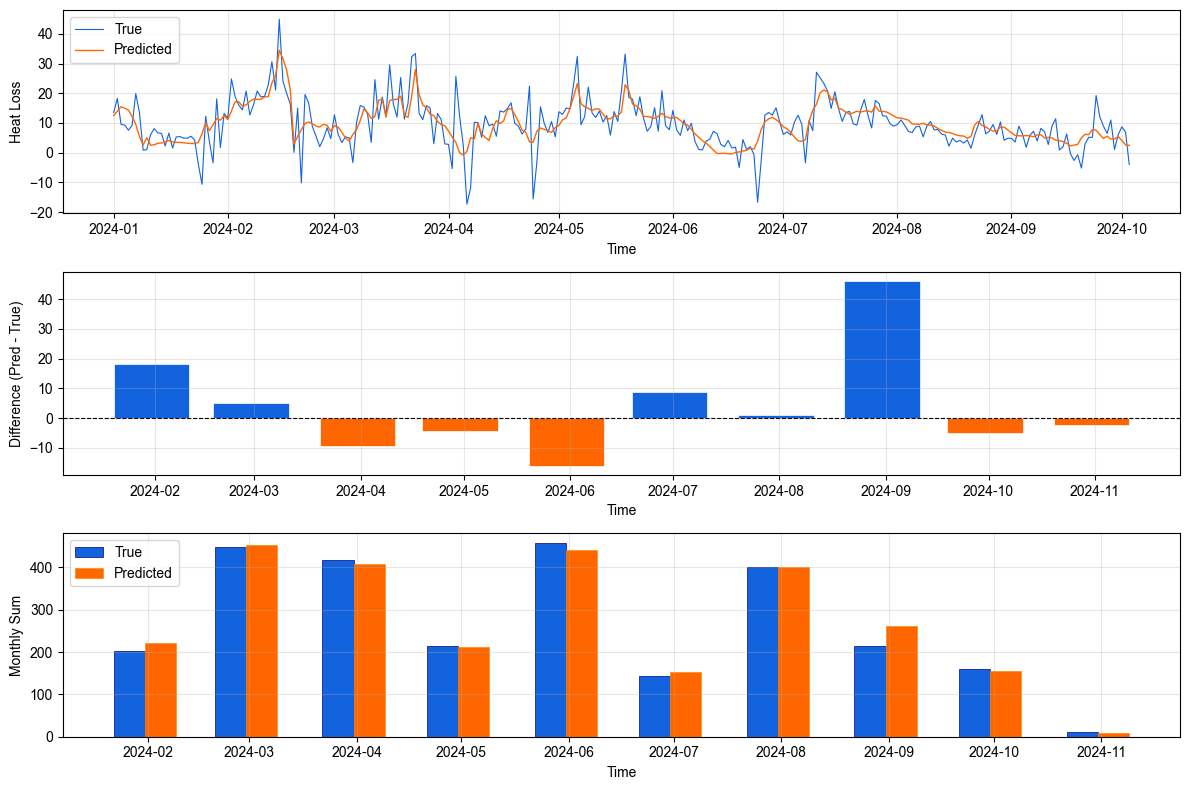

In [90]:
@jit(nopython=True)
def simulate_10R5C_numba(params, Ttop_vals, Tside_vals, Tbot_vals, Tair_vals, 
                          A_side, A_bot, A_top, T_inf):
    lam = 24*3600   # 1d
    U_soil_s, U_soil_b, UA_s_inf1, UA_s_inf2, UA_soilair1, UA_soilair2, UA_b_inf1, UA_b_inf2, \
    U_top, U_topair, C_top, C_s1, C_s2, C_b1, C_b2, Tt0, Ts1, Ts2, Tb1, Tb2 = params

    alpha_side1 = (U_soil_s * A_side) / C_s1
    beta_side1  = (UA_s_inf1) / C_s1
    theta_side1 = (UA_soilair1) / C_s1

    alpha_side2 = (UA_s_inf1) / C_s2  
    beta_side2  = (UA_s_inf2) / C_s2 
    theta_side2 = (UA_soilair2) / C_s2

    alpha_bot1 = (U_soil_b * A_bot) / C_b1  
    beta_bot1  = (UA_b_inf1) / C_b1  

    alpha_bot2 = (UA_b_inf1) / C_b2  
    beta_bot2  = (UA_b_inf2) / C_b2   

    alpha_top = (U_top * A_top) / C_top 
    beta_top  = (U_topair * A_top) / C_top 

    N = len(Tside_vals)
    T_t = np.zeros(N)
    T_s1 = np.zeros(N)
    T_s2 = np.zeros(N)
    T_b1 = np.zeros(N)
    T_b2 = np.zeros(N)
    T_t[0] = Tt0
    T_s1[0] = Ts1 
    T_s2[0] = Ts2
    T_b1[0] = Tb1
    T_b2[0] = Tb2

    for k in range(N-1):
        numer = T_s1[k] + lam*(alpha_side1*Tside_vals[k] + beta_side1*T_s2[k] + theta_side1*Tair_vals[k])
        denom = 1.0 + lam*(alpha_side1 + beta_side1 + theta_side1)
        T_s1[k+1] = numer / denom

        numer = T_s2[k] + lam*(alpha_side2*T_s1[k] + beta_side2*T_inf + theta_side2*Tair_vals[k])
        denom = 1.0 + lam*(alpha_side2 + beta_side2 + theta_side2)
        T_s2[k+1] = numer / denom

        numer = T_b1[k] + lam*(alpha_bot1*Tbot_vals[k+1] + beta_bot1*T_b2[k+1])
        denom = 1.0 + lam*(alpha_bot1 + beta_bot1)
        T_b1[k+1] = numer / denom

        numer = T_b2[k] + lam*(alpha_bot2*Tbot_vals[k+1] + beta_bot2*T_b1[k+1])
        denom = 1.0 + lam*(alpha_bot2 + beta_bot2)
        T_b2[k+1] = numer / denom

        numer = T_t[k] + lam*(alpha_top*Ttop_vals[k+1] + beta_top*Tair_vals[k+1])
        denom = 1.0 + lam*(alpha_top + beta_top)
        T_t[k+1] = numer / denom

    Q_b = (U_soil_b * A_bot) * (Tbot_vals - T_b1)  # W
    Q_t = (U_top * A_top) * (Ttop_vals - T_t)
    Q_s1 = (U_soil_s * A_side) * (Tside_vals - T_s1)
    Q = lam*(Q_b + Q_t + Q_s1) / 3.6e9
    
    return Q, T_t, T_s1, T_s2, T_b1, T_b2

def simulate_10R5C(params, Ttop, Tside, Tbot, Tair):
    params_array = np.array(params, dtype=np.float64)
    
    Ttop_vals = Ttop.values if hasattr(Ttop, 'values') else np.array(Ttop)
    Tside_vals = Tside.values if hasattr(Tside, 'values') else np.array(Tside)
    Tbot_vals = Tbot.values if hasattr(Tbot, 'values') else np.array(Tbot)
    Tair_vals = Tair.values if hasattr(Tair, 'values') else np.array(Tair)
    
    Q, T_t, T_s1, T_s2, T_b1, T_b2 = simulate_10R5C_numba(
        params_array,
        Ttop_vals, Tside_vals, Tbot_vals, Tair_vals,
        A_side,
        A_bot,
        A_top,
        T_inf)
    return pd.Series(Q, index=Tside.index), T_t, T_s1, T_s2, T_b1, T_b2

def objective(params_vec, T_watertop, T_waterside, T_waterbot, Tair, Q_obs):
    Q_total = simulate_10R5C(params_vec, T_watertop, T_waterside, T_waterbot, Tair)[0]
    loss = np.mean((Q_total - Q_obs)**2)
    return loss


def objective_unit(params_unit, T_watertop, T_waterside, T_waterbot, Tair, Q_obs, lb, ub):
    params_unit = clip_unit(params_unit)
    params_real = to_real(params_unit, lb, ub)
    return objective(params_real, T_watertop, T_waterside, T_waterbot, Tair, Q_obs)


def state_variable_model(trainx, trainy, testx, testy):
    train_T_watertop = trainx['watertop']
    train_T_waterside = trainx['waterside']
    train_T_waterbot = trainx['waterbot']
    train_Tair = trainx['Tam']

    train_Q = trainy

    test_T_watertop = testx['watertop']
    test_T_waterside = testx['waterside']
    test_T_waterbot = testx['waterbot']
    test_Tair = testx['Tam']
    
    bounds = [(0.01,90),      # U_soil_s 
              (0.01,90),      # U_soil_b 
              (1e0,1e5),      # UA_s_inf1
              (1e0,1e5),      # UA_s_inf2
              (1e0,1e5),      # UA_soilair1
              (1e0,1e5),      # UA_soilair2
              (1e0,1e5),      # UA_b_inf1
              (1e0,1e5),      # UA_b_inf2
              (0.01,90),      # U_top
              (0.01,90),      # U_topair
              (1e7,1e10),     # C_top
              (1e9,5e12),     # C_s1
              (1e9,5e12),     # C_s2
              (1e8,5e11),     # C_b1
              (1e8,5e11),     # C_b2
              (5,90),         # Tt0
              (5,90),         # Ts1
              (5,90),         # Ts2
              (5,90),         # Tb1
              (5,90)]         # Tb2
              
    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]

    args = (train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair, train_Q)

    bounds_unit = [(0.0, 1.0)] * len(bounds)
    model = differential_evolution(
        objective_unit, popsize=30,
        args=args + (lb, ub),
        bounds=bounds_unit, seed=42, disp=False)

    x_best_real = to_real(model.x, lb, ub)

    print("Optimization success:", model.success)
    print("Estimated parameters:")
    param_names = ['U_soil_s', 'U_soil_b', 'UA_s_inf1', 'UA_s_inf2','UA_soilair1','UA_soilair2','UA_b_inf1','UA_b_inf2', 
    'U_top','U_topair','C_top','C_s1','C_s2','C_b1','C_b2','Tt0','Ts1','Ts2','Tb1','Tb2']
    for name, val in zip(param_names, x_best_real):
        print(f"  {name:8s} = {val:.3e}")

    train_pred, T_t, T_s1, T_s2, T_b1, T_b2 = simulate_10R5C(x_best_real, train_T_watertop, train_T_waterside, train_T_waterbot, train_Tair)
    test_pred, T_t, T_s1, T_s2, T_b1, T_b2 = simulate_10R5C(x_best_real, test_T_watertop, test_T_waterside, test_T_waterbot, test_Tair)

    calculate_error_statistics(trainy, train_pred, testy, test_pred, model_name='Model')
    plot_compare(testy, test_pred)

    results_df = pd.DataFrame({
        'observed': testy,
        'predicted': test_pred
    })
    # results_df.to_csv('10R5C.csv', index=True, index_label='datetime')


waterside = water.mean(axis=1)
watertop = water['A_00.25m']
waterbot = water['A_13.80m']

water_input = pd.concat([watertop,waterbot,waterside,tair],axis=1)
water_input.columns = ['watertop','waterbot','waterside','Tam']

trainx = water_input[(water_input.index< '2024-07-01')]
trainy = heat_loss[(heat_loss.index< '2024-07-01')] 
testx = water_input
testy = heat_loss
state_variable_model(trainx, trainy, testx, testy)